# Preprocessing Pipeline — Retail Churn
Notebook généré à partir de `preprocessing.py` — avec affichage après chaque étape.

## 1. Imports

In [1]:
from __future__ import annotations

import ipaddress
import os
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

print('✅ Imports OK')

✅ Imports OK


## 2. Configuration

In [5]:
DEFAULT_RAW_PATH       = Path('../data/raw/retail_customers_COMPLETE_CATEGORICAL.csv')
DEFAULT_OUTPUT_DIR     = Path('data/train_test')
DEFAULT_PROCESSED_PATH = Path('data/processed/retail_customers_processed.csv')
TARGET_COL             = 'Churn'
RANDOM_STATE           = 42

print(f'📁 Raw data     : {DEFAULT_RAW_PATH}')
print(f'📁 Output dir   : {DEFAULT_OUTPUT_DIR}')
print(f'📁 Processed    : {DEFAULT_PROCESSED_PATH}')
print(f'🎯 Target col   : {TARGET_COL}')
print(f'🎲 Random state : {RANDOM_STATE}')

📁 Raw data     : ..\data\raw\retail_customers_COMPLETE_CATEGORICAL.csv
📁 Output dir   : data\train_test
📁 Processed    : data\processed\retail_customers_processed.csv
🎯 Target col   : Churn
🎲 Random state : 42


## 3. Définition des fonctions

In [9]:
def parse_registration_date(df: pd.DataFrame, col: str = 'RegistrationDate') -> pd.DataFrame:
    if col not in df.columns:
        return df
    dt = pd.to_datetime(df[col], dayfirst=True,format='mixed', errors='coerce')
    df = df.copy()
    df['RegYear']    = dt.dt.year
    df['RegMonth']   = dt.dt.month
    df['RegDay']     = dt.dt.day
    df['RegWeekday'] = dt.dt.weekday
    df.drop(columns=[col], inplace=True)
    return df


def featurize_ip(df: pd.DataFrame, col: str = 'LastLoginIP') -> pd.DataFrame:
    if col not in df.columns:
        return df

    def _is_private(ip_str):
        try:
            return float(ipaddress.ip_address(str(ip_str)).is_private)
        except Exception:
            return np.nan

    def _first_octet(ip_str):
        try:
            parts = str(ip_str).split('.')
            return float(int(parts[0])) if len(parts) == 4 else np.nan
        except Exception:
            return np.nan

    df = df.copy()
    df['IsPrivateIP']  = df[col].map(_is_private)
    df['IpFirstOctet'] = df[col].map(_first_octet)
    df.drop(columns=[col], inplace=True)
    return df


def add_feature_engineering(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if {'MonetaryTotal', 'Recency'}.issubset(df.columns):
        df['MonetaryPerDay'] = df['MonetaryTotal'] / (df['Recency'].astype(float) + 1.0)
    if {'MonetaryTotal', 'Frequency'}.issubset(df.columns):
        denom = df['Frequency'].replace(0, np.nan).astype(float)
        df['AvgBasketValue'] = df['MonetaryTotal'] / denom
    if {'Recency', 'CustomerTenureDays'}.issubset(df.columns):
        denom = df['CustomerTenureDays'].replace(0, np.nan).astype(float)
        df['TenureRatio'] = df['Recency'].astype(float) / denom
    return df


def drop_useless_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if 'CustomerID' in df.columns:
        df.drop(columns=['CustomerID'], inplace=True)
    nunique = df.nunique(dropna=False)
    constant_cols = nunique[nunique <= 1].index.tolist()
    if constant_cols:
        print(f'[Drop constants] Colonnes constantes supprimées : {constant_cols}')
        df.drop(columns=constant_cols, inplace=True)
    return df


def get_ordinal_mappings() -> Dict[str, List[str]]:
    return {
        'AgeCategory':        ['18-24', '25-34', '35-44', '45-54', '55-64', '65+', 'Inconnu'],
        'SpendingCategory':   ['Low', 'Medium', 'High', 'VIP'],
        'LoyaltyLevel':       ['Nouveau', 'Jeune', 'Établi', 'Ancien', 'Inconnu'],
        'ChurnRiskCategory':  ['Faible', 'Moyen', 'Élevé', 'Critique'],
        'BasketSizeCategory': ['Petit', 'Moyen', 'Grand', 'Inconnu'],
        'PreferredTimeOfDay': ['Matin', 'Midi', 'Après-midi', 'Soir', 'Nuit'],
    }


def infer_feature_groups(df: pd.DataFrame) -> Tuple[List[str], List[str], List[str]]:
    ordinal_map  = get_ordinal_mappings()
    ordinal_cols = [c for c in ordinal_map.keys() if c in df.columns]
    numeric_cols = [c for c in df.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns if c != TARGET_COL]
    nominal_cols = [c for c in df.select_dtypes(include=['object', 'string']).columns if c != TARGET_COL and c not in ordinal_cols]
    for extra in ['RegYear', 'RegMonth', 'RegDay', 'RegWeekday', 'IsPrivateIP', 'IpFirstOctet']:
        if extra in df.columns and extra not in numeric_cols and extra != TARGET_COL:
            numeric_cols.append(extra)
    def _unique(seq):
        seen, out = set(), []
        for x in seq:
            if x not in seen: seen.add(x); out.append(x)
        return out
    return _unique(numeric_cols), _unique(ordinal_cols), _unique(nominal_cols)


def build_preprocessor(numeric_cols, ordinal_cols, nominal_cols) -> ColumnTransformer:
    ordinal_map = get_ordinal_mappings()
    numeric_pipeline = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
    ordinal_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OrdinalEncoder(categories=[ordinal_map[c] for c in ordinal_cols],
                                   handle_unknown='use_encoded_value', unknown_value=-1)),
    ])
    nominal_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ])
    return ColumnTransformer(
        transformers=[('num', numeric_pipeline, numeric_cols),
                      ('ord', ordinal_pipeline, ordinal_cols),
                      ('nom', nominal_pipeline, nominal_cols)],
        remainder='drop', verbose_feature_names_out=False,
    )


def get_feature_names(preprocessor: ColumnTransformer) -> List[str]:
    try:
        return preprocessor.get_feature_names_out().tolist()
    except Exception:
        return []


def remove_correlated_features(X_train, X_test, threshold=0.90):
    corr_matrix = X_train.corr(numeric_only=True).abs()
    upper   = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
    if to_drop:
        print(f'[Corrélation] {len(to_drop)} feature(s) supprimée(s) (seuil={threshold}) : {to_drop}')
    else:
        print(f'[Corrélation] Aucune feature supprimée (seuil={threshold}).')
    return X_train.drop(columns=to_drop, errors='ignore'), X_test.drop(columns=to_drop, errors='ignore'), to_drop


def remove_high_vif_features(X_train, X_test, vif_threshold=10.0):
    try:
        from statsmodels.stats.outliers_influence import variance_inflation_factor
    except ImportError:
        print('[VIF] statsmodels non installé. Étape VIF ignorée.')
        return X_train, X_test, []
    num_cols = X_train.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns.tolist()
    if not num_cols:
        print('[VIF] Aucune colonne numérique. Étape VIF ignorée.')
        return X_train, X_test, []
    dropped, current_cols = [], num_cols.copy()
    while True:
        X_vif = X_train[current_cols].dropna()
        if X_vif.shape[1] < 2: break
        vif_data = pd.Series([variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])], index=current_cols)
        max_vif = vif_data.max()
        if max_vif <= vif_threshold: break
        worst = vif_data.idxmax()
        print(f"[VIF] Suppression de '{worst}' (VIF={max_vif:.2f} > {vif_threshold})")
        current_cols.remove(worst); dropped.append(worst)
    if not dropped:
        print(f'[VIF] Aucune feature supprimée (seuil={vif_threshold}).')
    return X_train.drop(columns=dropped, errors='ignore'), X_test.drop(columns=dropped, errors='ignore'), dropped


def load_raw_dataset(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f'Raw dataset not found at: {path}')
    return pd.read_csv(path)


def prepare_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if TARGET_COL not in df.columns:
        raise ValueError(f"Target column '{TARGET_COL}' not found in dataset.")
    df = parse_registration_date(df, 'RegistrationDate')
    df = featurize_ip(df, 'LastLoginIP')
    df = add_feature_engineering(df)
    df = drop_useless_features(df)
    return df

print('✅ Toutes les fonctions sont définies')

✅ Toutes les fonctions sont définies


---
## 4. Exécution pas-à-pas avec affichage

### 4.1 — `load_raw_dataset`

In [6]:
df_raw = load_raw_dataset(DEFAULT_RAW_PATH)

In [7]:
# ── Affichage après load_raw_dataset ──────────────────────────
print(f'📐 Dimensions       : {df_raw.shape[0]} lignes × {df_raw.shape[1]} colonnes')
print(f'🎯 Distribution cible ({TARGET_COL}) :')
print(df_raw[TARGET_COL].value_counts(normalize=True).rename('proportion').round(4).to_string())
print('\n🔍 Aperçu (5 premières lignes) :')
df_raw.head()

📐 Dimensions       : 4372 lignes × 52 colonnes
🎯 Distribution cible (Churn) :
Churn
0    0.6674
1    0.3326

🔍 Aperçu (5 premières lignes) :


,CustomerID,Recency,Frequency,MonetaryTotal,MonetaryAvg,MonetaryStd,MonetaryMin,MonetaryMax,TotalQuantity,AvgQuantityPerTransaction,...,Region,LoyaltyLevel,ChurnRiskCategory,WeekendPreference,BasketSizeCategory,ProductDiversity,Gender,AccountStatus,Country,Churn
0,17850,302,35,5288.63,16.950737,13.603662,-30.60,107.25,1693,5.426282,...,UK,Jeune,Critique,Inconnu,Moyen,Explorateur,Unknown,Active,United Kingdom,1
1,13047,32,18,3079.10,15.709694,11.684769,-15.00,68.00,1355,6.913265,...,UK,Établi,Moyen,Semaine,Moyen,Explorateur,M,Active,United Kingdom,0
2,12583,3,18,7187.34,28.634821,23.150132,-60.84,132.80,5009,19.956175,...,Europe continentale,Ancien,Faible,Semaine,Grand,Explorateur,Unknown,Active,France,0
3,13748,96,5,948.25,33.866071,42.953119,9.36,204.00,439,15.678571,...,UK,Établi,Critique,Inconnu,Grand,Explorateur,Unknown,Active,United Kingdom,1
4,15100,330,6,635.10,105.850000,215.986263,-131.40,350.40,58,9.666667,...,UK,Jeune,Critique,Inconnu,Moyen,Spécialisé,M,Active,United Kingdom,1


### 4.2 — `parse_registration_date`

In [10]:
df_after_date = parse_registration_date(df_raw.copy(), 'RegistrationDate')

In [12]:
# ── Affichage après parse_registration_date ───────────────────
new_cols = ['RegYear', 'RegMonth', 'RegDay', 'RegWeekday']
present  = [c for c in new_cols if c in df_after_date.columns]
print(f'✅ Colonnes créées          : {present}')
print(f'🗑️  RegistrationDate supprimée : {"RegistrationDate" not in df_after_date.columns}')
print(f'📐 Nouvelles dimensions     : {df_after_date.shape}')
print()
print("=== Aperçu des données ===")
display(df_after_date[present].head(10))

print("\n=== Statistiques descriptives ===")
display(df_after_date[present].describe().round(1))


✅ Colonnes créées          : ['RegYear', 'RegMonth', 'RegDay', 'RegWeekday']
🗑️  RegistrationDate supprimée : True
📐 Nouvelles dimensions     : (4372, 55)

=== Aperçu des données ===


,RegYear,RegMonth,RegDay,RegWeekday
0,2010,7,17,5
1,2010,4,10,5
2,2009,9,12,5
3,2010,1,28,3
4,2009,10,12,0
5,2010,10,18,0
6,2010,11,2,1
7,2010,12,17,4
8,2010,9,23,3
9,2010,9,4,5



=== Statistiques descriptives ===


,RegYear,RegMonth,RegDay,RegWeekday
count,4372.0,4372.0,4372.0,4372.0
mean,2010.5,6.8,15.7,3.0
std,0.5,3.5,8.7,2.0
min,2009.0,1.0,1.0,0.0
25%,2010.0,4.0,9.0,1.0
50%,2011.0,7.0,15.0,3.0
75%,2011.0,10.0,23.0,5.0
max,2011.0,12.0,31.0,6.0


### 4.3 — `featurize_ip`

In [13]:
df_after_ip = featurize_ip(df_after_date.copy(), 'LastLoginIP')

In [17]:
# ── Affichage après featurize_ip ──────────────────────────────
ip_cols = ['IsPrivateIP', 'IpFirstOctet']
present_ip = [c for c in ip_cols if c in df_after_ip.columns]
print(f'✅ Colonnes créées       : {present_ip}')
print(f'🗑️  LastLoginIP supprimée : {"LastLoginIP" not in df_after_ip.columns}')
print(f'📐 Nouvelles dimensions  : {df_after_ip.shape}')
display(df_after_ip[present_ip].head(10))
print('\n🔒 IsPrivateIP — distribution :')
print(df_after_ip['IsPrivateIP'].value_counts(dropna=False).to_string())
print('\n🌐 IpFirstOctet — statistiques :')
print(df_after_ip['IpFirstOctet'].describe().round(2).to_string())

✅ Colonnes créées       : ['IsPrivateIP', 'IpFirstOctet']
🗑️  LastLoginIP supprimée : True
📐 Nouvelles dimensions  : (4372, 56)


,IsPrivateIP,IpFirstOctet
0,0.0,59.0
1,0.0,77.0
2,0.0,51.0
3,1.0,10.0
4,0.0,186.0
5,0.0,206.0
6,0.0,154.0
7,0.0,98.0
8,0.0,199.0
9,0.0,114.0



🔒 IsPrivateIP — distribution :
IsPrivateIP
0.0    4046
1.0     326

🌐 IpFirstOctet — statistiques :
count    4372.00
mean      128.13
std        74.71
min         1.00
25%        62.75
50%       127.00
75%       194.00
max       255.00


### 4.4 — `add_feature_engineering`

In [15]:
df_after_fe = add_feature_engineering(df_after_ip.copy())

In [16]:
# ── Affichage après add_feature_engineering ───────────────────
ratio_cols = ['MonetaryPerDay', 'AvgBasketValue', 'TenureRatio']
present_fe = [c for c in ratio_cols if c in df_after_fe.columns]
print(f'✅ Nouvelles features ratio : {present_fe}')
print(f'📐 Nouvelles dimensions    : {df_after_fe.shape}')
print()
df_after_fe[present_fe].describe().round(3)

✅ Nouvelles features ratio : ['MonetaryPerDay', 'AvgBasketValue', 'TenureRatio']
📐 Nouvelles dimensions    : (4372, 59)



,MonetaryPerDay,AvgBasketValue,TenureRatio
count,4372.000,4372.000,2980.000
mean,295.772,315.883,3.047
std,2869.516,361.237,15.990
min,-29.367,-4287.630,0.003
25%,2.780,151.991,0.052
50%,13.189,236.988,0.177
75%,70.087,370.816,0.706
max,128219.245,6207.670,316.000


### 4.5 — `drop_useless_features`

In [18]:
cols_before  = set(df_after_fe.columns)
df_after_drop = drop_useless_features(df_after_fe.copy())

[Drop constants] Colonnes constantes supprimées : ['NewsletterSubscribed']


In [19]:
# ── Affichage après drop_useless_features ─────────────────────
cols_after = set(df_after_drop.columns)
removed    = sorted(cols_before - cols_after)
print(f'🗑️  Colonnes supprimées ({len(removed)}) : {removed if removed else "aucune"}')
print(f'📐 Avant : {len(cols_before)} cols  →  Après : {len(cols_after)} cols')
print(f'\n📋 Colonnes restantes :')
print(sorted(df_after_drop.columns.tolist()))

🗑️  Colonnes supprimées (2) : ['CustomerID', 'NewsletterSubscribed']
📐 Avant : 59 cols  →  Après : 57 cols

📋 Colonnes restantes :
['AccountStatus', 'Age', 'AgeCategory', 'AvgBasketValue', 'AvgDaysBetweenPurchases', 'AvgLinesPerInvoice', 'AvgProductsPerTransaction', 'AvgQuantityPerTransaction', 'BasketSizeCategory', 'CancelledTransactions', 'Churn', 'ChurnRiskCategory', 'Country', 'CustomerTenureDays', 'CustomerType', 'FavoriteSeason', 'FirstPurchaseDaysAgo', 'Frequency', 'Gender', 'IpFirstOctet', 'IsPrivateIP', 'LoyaltyLevel', 'MaxQuantity', 'MinQuantity', 'MonetaryAvg', 'MonetaryMax', 'MonetaryMin', 'MonetaryPerDay', 'MonetaryStd', 'MonetaryTotal', 'NegativeQuantityCount', 'PreferredDayOfWeek', 'PreferredHour', 'PreferredMonth', 'PreferredTimeOfDay', 'ProductDiversity', 'RFMSegment', 'Recency', 'RegDay', 'RegMonth', 'RegWeekday', 'RegYear', 'Region', 'ReturnRatio', 'SatisfactionScore', 'SpendingCategory', 'SupportTicketsCount', 'TenureRatio', 'TotalQuantity', 'TotalTransactions', 'Un

### 4.6 — `prepare_dataframe` (pipeline pré-split complet)

In [20]:
df_prepared = prepare_dataframe(df_raw)

[Drop constants] Colonnes constantes supprimées : ['NewsletterSubscribed']


In [21]:
# ── Affichage après prepare_dataframe ─────────────────────────
print(f'📐 Dimensions finales : {df_prepared.shape[0]} lignes × {df_prepared.shape[1]} colonnes')
print(f'\n❓ Valeurs manquantes (top 10) :')
missing = df_prepared.isnull().sum()
top_missing = missing[missing > 0].sort_values(ascending=False).head(10)
print(top_missing.to_string() if len(top_missing) else '  → Aucune valeur manquante')
print(f'\n🔢 Types de colonnes :')
print(df_prepared.dtypes.value_counts().to_string())
print()
df_prepared.head()

📐 Dimensions finales : 4372 lignes × 57 colonnes

❓ Valeurs manquantes (top 10) :
TenureRatio                1392
Age                        1311
AvgDaysBetweenPurchases      79

🔢 Types de colonnes :
int64      19
float64    19
str        15
int32       4



,Recency,Frequency,MonetaryTotal,MonetaryAvg,MonetaryStd,MonetaryMin,MonetaryMax,TotalQuantity,AvgQuantityPerTransaction,MinQuantity,...,Churn,RegYear,RegMonth,RegDay,RegWeekday,IsPrivateIP,IpFirstOctet,MonetaryPerDay,AvgBasketValue,TenureRatio
0,302,35,5288.63,16.950737,13.603662,-30.60,107.25,1693,5.426282,-12,...,1,2010,7,17,5,0.0,59.0,17.454224,151.103714,4.253521
1,32,18,3079.10,15.709694,11.684769,-15.00,68.00,1355,6.913265,-3,...,0,2010,4,10,5,0.0,77.0,93.306061,171.061111,0.093567
2,3,18,7187.34,28.634821,23.150132,-60.84,132.80,5009,19.956175,-36,...,0,2009,9,12,5,0.0,51.0,1796.835000,399.296667,0.008108
3,96,5,948.25,33.866071,42.953119,9.36,204.00,439,15.678571,1,...,1,2010,1,28,3,1.0,10.0,9.775773,189.650000,0.345324
4,330,6,635.10,105.850000,215.986263,-131.40,350.40,58,9.666667,-12,...,1,2009,10,12,0,0.0,186.0,1.918731,105.850000,7.674419


### 4.7 — `get_ordinal_mappings`

In [22]:
ordinal_mappings = get_ordinal_mappings()

In [23]:
# ── Affichage après get_ordinal_mappings ──────────────────────
print(f'📚 {len(ordinal_mappings)} colonnes ordinales définies :')
for col, cats in ordinal_mappings.items():
    print(f'  • {col:<25} → {cats}')

📚 6 colonnes ordinales définies :
  • AgeCategory               → ['18-24', '25-34', '35-44', '45-54', '55-64', '65+', 'Inconnu']
  • SpendingCategory          → ['Low', 'Medium', 'High', 'VIP']
  • LoyaltyLevel              → ['Nouveau', 'Jeune', 'Établi', 'Ancien', 'Inconnu']
  • ChurnRiskCategory         → ['Faible', 'Moyen', 'Élevé', 'Critique']
  • BasketSizeCategory        → ['Petit', 'Moyen', 'Grand', 'Inconnu']
  • PreferredTimeOfDay        → ['Matin', 'Midi', 'Après-midi', 'Soir', 'Nuit']


### 4.8 — `train_test_split`

In [24]:
test_size = 0.2

X = df_prepared.drop(columns=[TARGET_COL])
y = df_prepared[TARGET_COL].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_size, random_state=RANDOM_STATE, stratify=y
)

In [25]:
# ── Affichage après train_test_split ──────────────────────────
print(f'✂️  Split stratifié (test_size={test_size})')
print(f'   X_train : {X_train.shape}  |  X_test : {X_test.shape}')
print(f'   y_train : {y_train.shape}  |  y_test : {y_test.shape}')
print(f'\n📊 Distribution cible — train :')
print(y_train.value_counts(normalize=True).rename('proportion').round(4).to_string())
print(f'\n📊 Distribution cible — test :')
print(y_test.value_counts(normalize=True).rename('proportion').round(4).to_string())

✂️  Split stratifié (test_size=0.2)
   X_train : (3497, 56)  |  X_test : (875, 56)
   y_train : (3497,)  |  y_test : (875,)

📊 Distribution cible — train :
Churn
0    0.6674
1    0.3326

📊 Distribution cible — test :
Churn
0    0.6674
1    0.3326


### 4.9 — `infer_feature_groups`

In [26]:
numeric_cols, ordinal_cols, nominal_cols = infer_feature_groups(X_train)

In [27]:
# ── Affichage après infer_feature_groups ──────────────────────
print(f'🔢 Numériques  ({len(numeric_cols)}) :')
print(f'   {numeric_cols}')
print(f'\n📶 Ordinales   ({len(ordinal_cols)}) :')
print(f'   {ordinal_cols}')
print(f'\n🏷️  Nominales   ({len(nominal_cols)}) :')
print(f'   {nominal_cols}')
print(f'\n📦 Total features en entrée : {len(numeric_cols) + len(ordinal_cols) + len(nominal_cols)}')

🔢 Numériques  (41) :
   ['Recency', 'Frequency', 'MonetaryTotal', 'MonetaryAvg', 'MonetaryStd', 'MonetaryMin', 'MonetaryMax', 'TotalQuantity', 'AvgQuantityPerTransaction', 'MinQuantity', 'MaxQuantity', 'CustomerTenureDays', 'FirstPurchaseDaysAgo', 'PreferredDayOfWeek', 'PreferredHour', 'PreferredMonth', 'WeekendPurchaseRatio', 'AvgDaysBetweenPurchases', 'UniqueProducts', 'UniqueDescriptions', 'AvgProductsPerTransaction', 'UniqueCountries', 'NegativeQuantityCount', 'ZeroPriceCount', 'CancelledTransactions', 'ReturnRatio', 'TotalTransactions', 'UniqueInvoices', 'AvgLinesPerInvoice', 'Age', 'SupportTicketsCount', 'SatisfactionScore', 'RegYear', 'RegMonth', 'RegDay', 'RegWeekday', 'IsPrivateIP', 'IpFirstOctet', 'MonetaryPerDay', 'AvgBasketValue', 'TenureRatio']

📶 Ordinales   (6) :
   ['AgeCategory', 'SpendingCategory', 'LoyaltyLevel', 'ChurnRiskCategory', 'BasketSizeCategory', 'PreferredTimeOfDay']

🏷️  Nominales   (9) :
   ['RFMSegment', 'CustomerType', 'FavoriteSeason', 'Region', 'Weeke

### 4.10 — `build_preprocessor`

In [28]:
preprocessor = build_preprocessor(numeric_cols, ordinal_cols, nominal_cols)

In [29]:
# ── Affichage après build_preprocessor ───────────────────────
print('🔧 Preprocessor construit :')
for name, pipe, cols in preprocessor.transformers:
    steps = ' → '.join([s for s, _ in pipe.steps]) if hasattr(pipe, 'steps') else str(pipe)
    print(f'   [{name}] {len(cols)} colonnes  |  étapes : {steps}')
print()
preprocessor

🔧 Preprocessor construit :
   [num] 41 colonnes  |  étapes : imputer → scaler
   [ord] 6 colonnes  |  étapes : imputer → encoder
   [nom] 9 colonnes  |  étapes : imputer → onehot



,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ord', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e

### 4.11 — `fit_transform` (train) + `transform` (test) + `get_feature_names`

In [30]:
X_train_arr = preprocessor.fit_transform(X_train)
X_test_arr  = preprocessor.transform(X_test)

feature_names = get_feature_names(preprocessor)

if feature_names and len(feature_names) == X_train_arr.shape[1]:
    X_train_df = pd.DataFrame(X_train_arr, columns=feature_names)
    X_test_df  = pd.DataFrame(X_test_arr,  columns=feature_names)
else:
    X_train_df = pd.DataFrame(X_train_arr)
    X_test_df  = pd.DataFrame(X_test_arr)

In [31]:
# ── Affichage après fit_transform / transform ─────────────────
print(f'⚙️  Features après encodage  : {X_train_df.shape[1]}')
print(f'   X_train_df : {X_train_df.shape}')
print(f'   X_test_df  : {X_test_df.shape}')
print(f'\n❓ NaN dans X_train_df : {X_train_df.isnull().sum().sum()}')
print(f'❓ NaN dans X_test_df  : {X_test_df.isnull().sum().sum()}')
print(f'\n📋 10 premières features :')
print(feature_names[:10])
print()
X_train_df.describe().round(3).T.head(10)

⚙️  Features après encodage  : 122
   X_train_df : (3497, 122)
   X_test_df  : (875, 122)

❓ NaN dans X_train_df : 0
❓ NaN dans X_test_df  : 0

📋 10 premières features :
['Recency', 'Frequency', 'MonetaryTotal', 'MonetaryAvg', 'MonetaryStd', 'MonetaryMin', 'MonetaryMax', 'TotalQuantity', 'AvgQuantityPerTransaction', 'MinQuantity']



,count,mean,std,min,25%,50%,75%,max
Recency,3497.0,0.0,1.0,-0.907,-0.747,-0.419,0.507,2.806
Frequency,3497.0,0.0,1.0,-0.422,-0.422,-0.218,0.088,24.765
MonetaryTotal,3497.0,-0.0,1.0,-0.814,-0.211,-0.165,-0.036,33.429
MonetaryAvg,3497.0,-0.0,1.0,-31.461,-0.137,-0.095,-0.045,27.916
MonetaryStd,3497.0,-0.0,1.0,-0.035,-0.033,-0.032,-0.028,45.725
MonetaryMin,3497.0,0.0,1.0,-52.367,0.029,0.033,0.035,1.233
MonetaryMax,3497.0,0.0,1.0,-1.396,-0.054,-0.047,-0.031,52.279
TotalQuantity,3497.0,0.0,1.0,-0.373,-0.252,-0.196,-0.033,20.171
AvgQuantityPerTransaction,3497.0,-0.0,1.0,-1.639,-0.140,-0.101,-0.056,42.897
MinQuantity,3497.0,0.0,1.0,-43.347,0.026,0.028,0.028,2.330


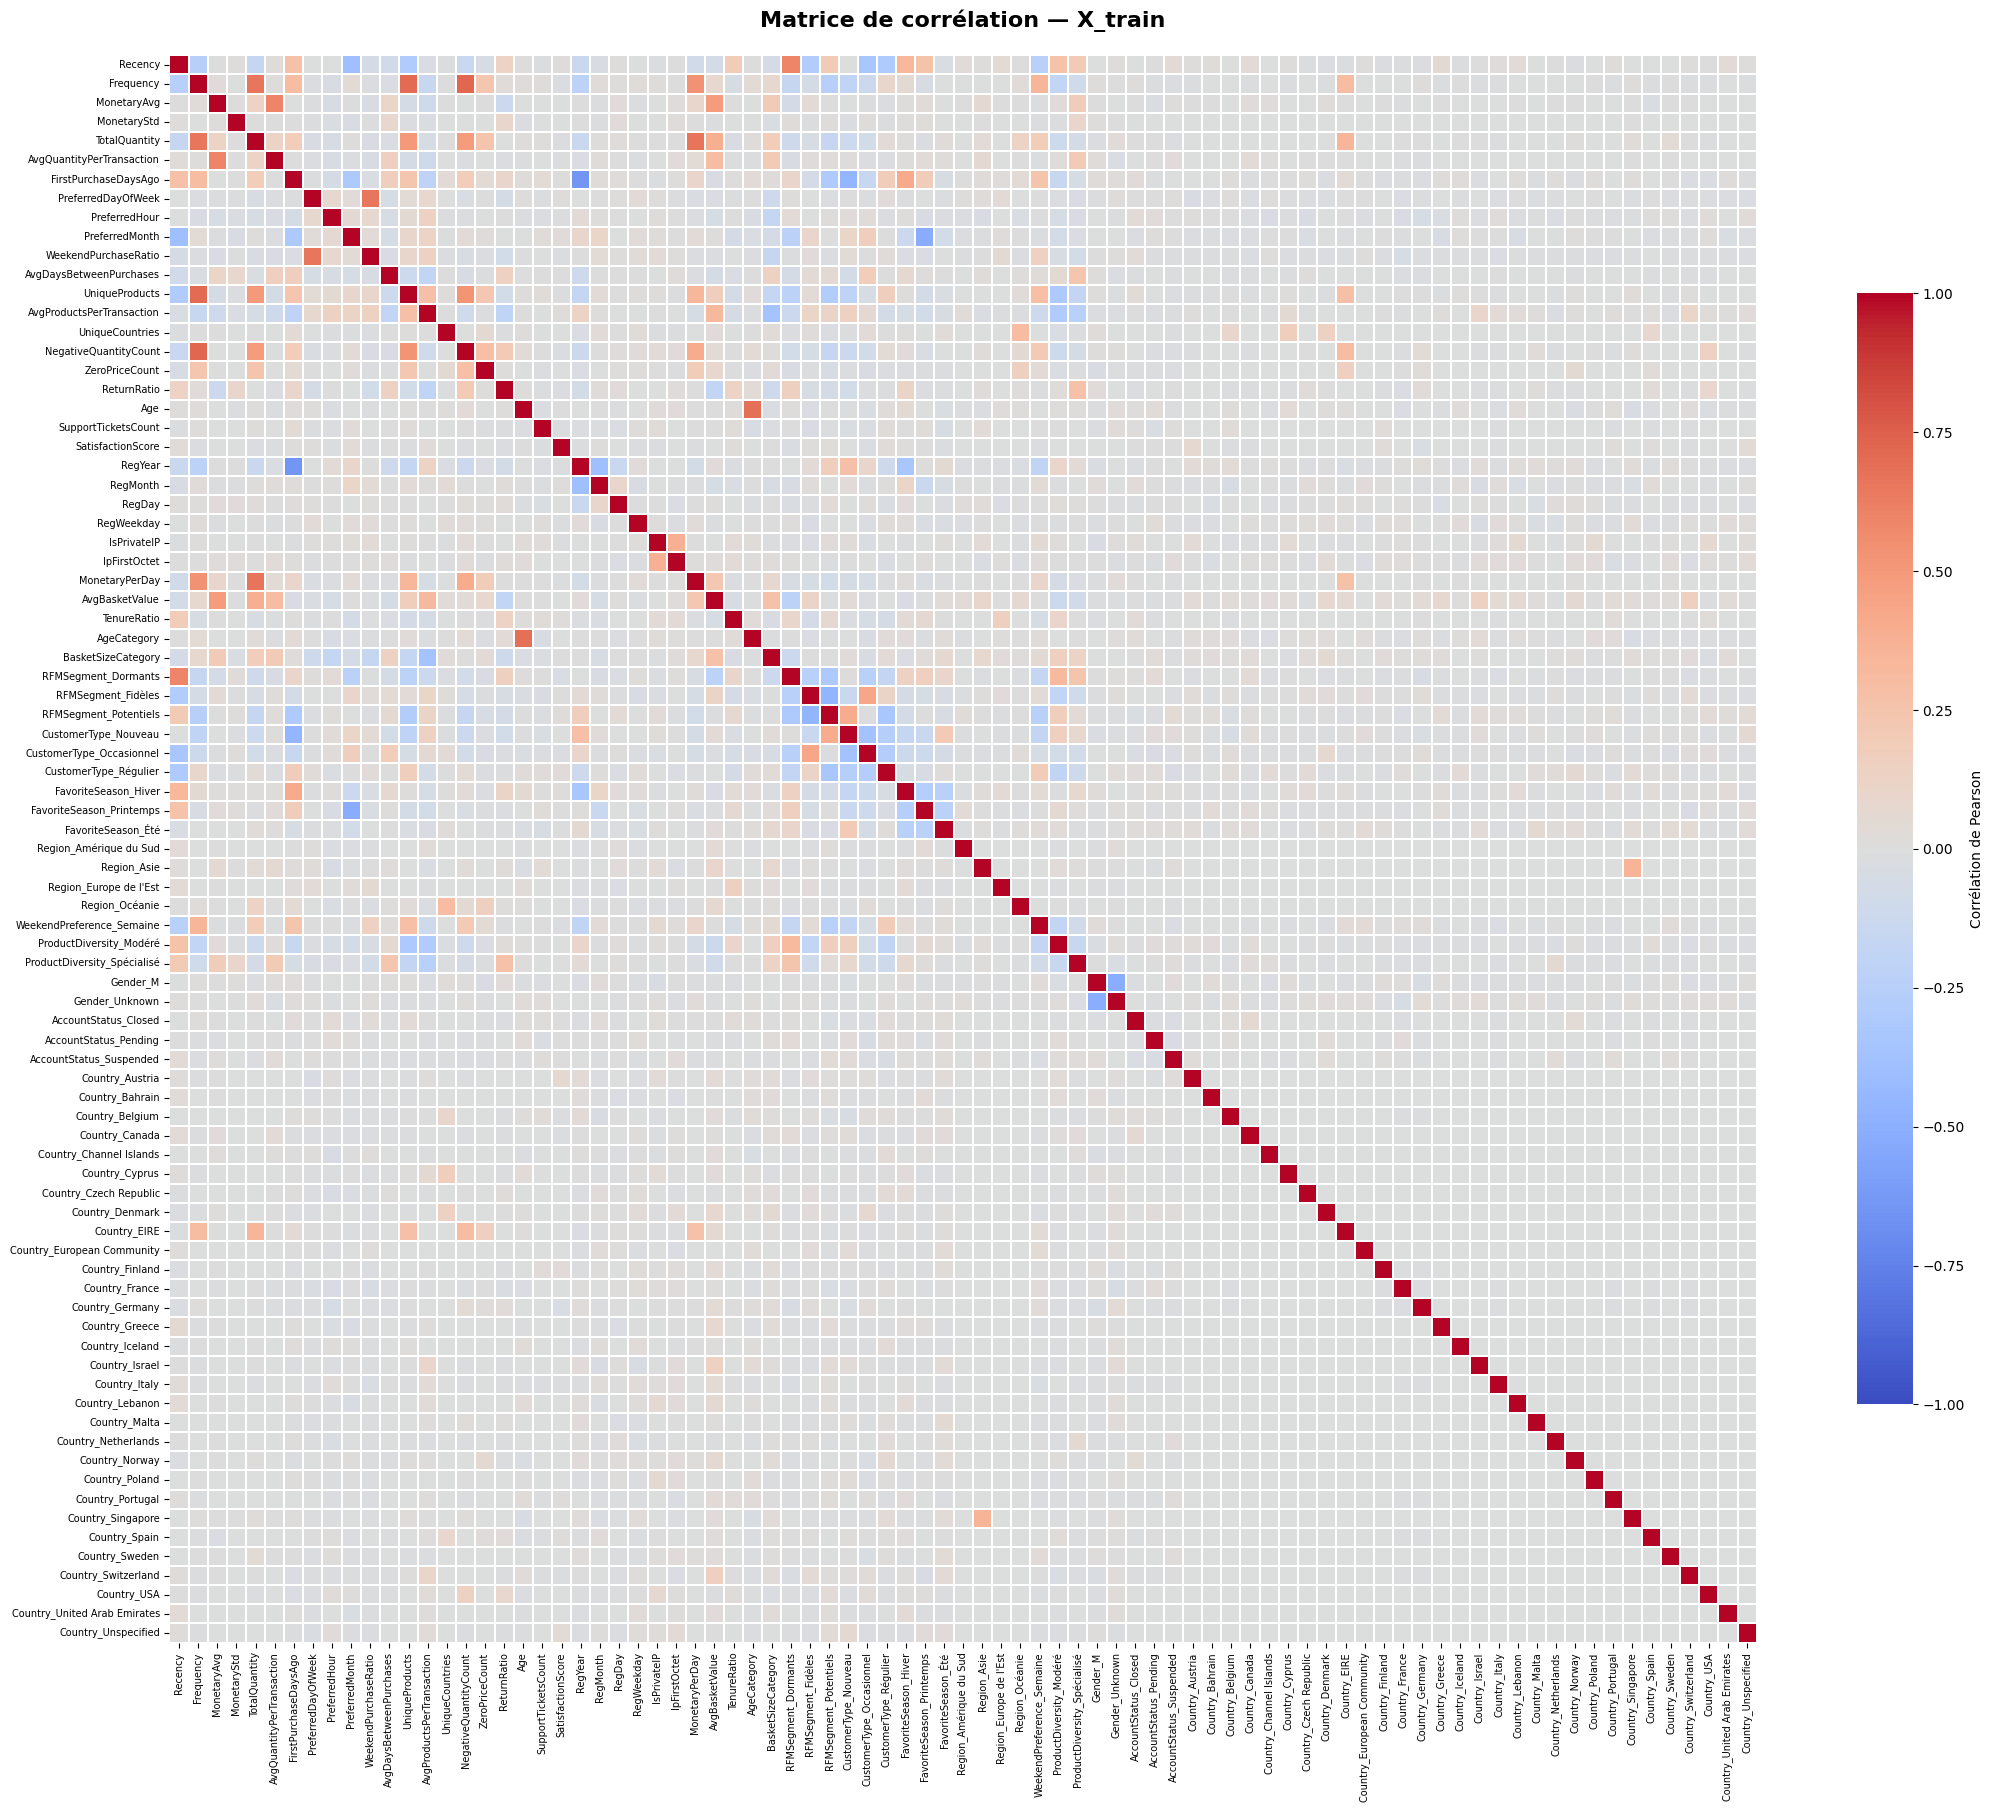

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_matrix = X_train_df.corr(numeric_only=True)

plt.figure(figsize=(22, 18))
sns.heatmap(
    corr_matrix,
    annot=False,        # pas de chiffres pour rester lisible
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.3,
    square=True,
    cbar_kws={"shrink": 0.7, "label": "Corrélation de Pearson"}
)
plt.title("Matrice de corrélation — X_train", fontsize=16, fontweight="bold", pad=20)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0,  fontsize=7)
plt.tight_layout()
plt.show()

### 4.12 — `remove_correlated_features`

In [40]:
corr_threshold = 0.7

X_train_df, X_test_df, dropped_corr = remove_correlated_features(
    X_train_df, X_test_df, threshold=corr_threshold
)

[Corrélation] 2 feature(s) supprimée(s) (seuil=0.7) : ['UniqueProducts', 'NegativeQuantityCount']


In [41]:
# ── Affichage après remove_correlated_features ────────────────
print(f'🔗 Seuil de corrélation      : {corr_threshold}')
print(f'🗑️  Features supprimées ({len(dropped_corr)}) : {dropped_corr if dropped_corr else "aucune"}')
print(f'📐 X_train_df : {X_train_df.shape}  |  X_test_df : {X_test_df.shape}')

# Top 5 paires corrélées restantes
corr = X_train_df.corr(numeric_only=True).abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
print(f'\n📊 Top 5 paires corrélées restantes :')
print(upper.sort_values(ascending=False).head(5).round(4).to_string())

🔗 Seuil de corrélation      : 0.7
🗑️  Features supprimées (2) : ['UniqueProducts', 'NegativeQuantityCount']
📐 X_train_df : (3497, 81)  |  X_test_df : (875, 81)

📊 Top 5 paires corrélées restantes :
Age                   AgeCategory             0.6853
TotalQuantity         MonetaryPerDay          0.6649
Frequency             TotalQuantity           0.6620
PreferredDayOfWeek    WeekendPurchaseRatio    0.6598
FirstPurchaseDaysAgo  RegYear                 0.6425


### 4.13 — `remove_high_vif_features`

In [42]:
vif_threshold = 10.0

X_train_df, X_test_df, dropped_vif = remove_high_vif_features(
    X_train_df, X_test_df, vif_threshold=vif_threshold
)

[VIF] Aucune feature supprimée (seuil=10.0).


In [43]:
# ── Affichage après remove_high_vif_features ──────────────────
print(f'📏 Seuil VIF                 : {vif_threshold}')
print(f'🗑️  Features supprimées ({len(dropped_vif)}) : {dropped_vif if dropped_vif else "aucune"}')
print(f'📐 X_train_df : {X_train_df.shape}  |  X_test_df : {X_test_df.shape}')

📏 Seuil VIF                 : 10.0
🗑️  Features supprimées (0) : aucune
📐 X_train_df : (3497, 81)  |  X_test_df : (875, 81)


### 4.14 — Sauvegarde des fichiers

In [44]:
output_dir     = DEFAULT_OUTPUT_DIR
processed_path = DEFAULT_PROCESSED_PATH

output_dir.mkdir(parents=True, exist_ok=True)
processed_path.parent.mkdir(parents=True, exist_ok=True)

X_train_df.to_csv(output_dir / 'X_train.csv', index=False)
X_test_df.to_csv(output_dir  / 'X_test.csv',  index=False)
y_train.to_frame(name=TARGET_COL).to_csv(output_dir / 'y_train.csv', index=False)
y_test.to_frame(name=TARGET_COL).to_csv(output_dir  / 'y_test.csv',  index=False)

# Dataset complet transformé
X_all_arr = preprocessor.transform(X)
X_all_df  = pd.DataFrame(X_all_arr, columns=feature_names) if feature_names and len(feature_names) == X_all_arr.shape[1] else pd.DataFrame(X_all_arr)
X_all_df  = X_all_df[[c for c in X_train_df.columns if c in X_all_df.columns]]
df_processed = X_all_df.copy()
df_processed[TARGET_COL] = y.values
df_processed.to_csv(processed_path, index=False)

In [45]:
# ── Affichage après sauvegarde ────────────────────────────────
saved = {
    'X_train.csv' : output_dir / 'X_train.csv',
    'X_test.csv'  : output_dir / 'X_test.csv',
    'y_train.csv' : output_dir / 'y_train.csv',
    'y_test.csv'  : output_dir / 'y_test.csv',
    'processed'   : processed_path,
}
print('💾 Fichiers sauvegardés :')
for label, path in saved.items():
    exists = path.exists()
    size   = f'{os.path.getsize(path) / 1024:.1f} Ko' if exists else '—'
    print(f'   {"✅" if exists else "❌"} {label:<15} {str(path):<55} {size}')

💾 Fichiers sauvegardés :
   ✅ X_train.csv     data\train_test\X_train.csv                             2658.0 Ko
   ✅ X_test.csv      data\train_test\X_test.csv                              666.2 Ko
   ✅ y_train.csv     data\train_test\y_train.csv                             10.3 Ko
   ✅ y_test.csv      data\train_test\y_test.csv                              2.6 Ko
   ✅ processed       data\processed\retail_customers_processed.csv           3331.4 Ko


---
## 5. Récapitulatif final

In [46]:
print('=' * 58)
print('         RÉCAPITULATIF DU PRÉTRAITEMENT')
print('=' * 58)
print(f'  Lignes totales           : {df_raw.shape[0]}')
print(f'  Features brutes          : {df_raw.shape[1]}')
print(f'  Features après encodage  : {len(feature_names)}')
print(f'  Supprimées (corrélation) : {len(dropped_corr)}')
print(f'  Supprimées (VIF)         : {len(dropped_vif)}')
print(f'  ──────────────────────────────────────')
print(f'  Features finales         : {X_train_df.shape[1]}')
print(f'  Taille train             : {X_train_df.shape[0]} lignes')
print(f'  Taille test              : {X_test_df.shape[0]} lignes')
print('=' * 58)
print('✅ Prétraitement terminé !')

         RÉCAPITULATIF DU PRÉTRAITEMENT
  Lignes totales           : 4372
  Features brutes          : 52
  Features après encodage  : 122
  Supprimées (corrélation) : 2
  Supprimées (VIF)         : 0
  ──────────────────────────────────────
  Features finales         : 81
  Taille train             : 3497 lignes
  Taille test              : 875 lignes
✅ Prétraitement terminé !
